# Homework 1B: Bootstrap a Rate Difference

This assignment uses a supplied rate-difference statistic to compare purchase-session rates for new and returning visitors. You will inspect one bootstrap replicate, use a bootstrap distribution to estimate uncertainty, and compare two resampling designs. The statistic illustrates the structure requested in HW1a, but you do not need your HW1a work to complete this assignment.

You may use an LLM to help you understand the supplied code. The explanations you submit must be your own and should show that you understand how the code works; do not simply reproduce an answer written by a tool. Disclose any material assistance at the end.

## Online shopping sessions

An e-commerce analytics team wants to compare sessions from visitors classified as new or returning. The recorded outcome is whether the session ended in a purchase. The team needs an interval estimate for the difference in purchase-session rates, not only the observed difference.

The original data come from the [UCI Online Shoppers Purchasing Intention Dataset](https://doi.org/10.24432/C5F88Q). The course-prepared extract retains 12,245 sessions classified as new or returning and the three fields needed here. The source states that each session belongs to a different user during the recorded one-year period. The source does not document enough about the site, sampling frame, or visitor-classification process to assume that these sessions represent every e-commerce setting.

The extract excludes 85 sessions labeled `Other`. Use the provided extract rather than substituting the original file.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import bootstrap

sessions = pd.read_csv(
    "https://raw.githubusercontent.com/olearydj/INSY7130/"
    "main/homework/hw1b/data/online-shopping-sessions.csv"
)
sessions.shape

(12245, 3)

In [2]:
sessions.head()

,visitor_type,weekend,purchase
0,returning,False,False
1,returning,False,False
2,returning,False,False
3,returning,False,False
4,returning,True,False


The following summary shows the group sizes and observed purchase-session rates.

In [3]:
session_summary = (
    sessions.groupby("visitor_type")["purchase"]
    .agg(sessions="size", purchase_rate="mean")
    .reindex(["new", "returning"])
)
session_summary

,sessions,purchase_rate
visitor_type,,
new,1694,0.249115
returning,10551,0.139323


In one short response, identify the analytical object, the two groups, the binary outcome, and one limitation on using this file to represent a broader population or setting.

**Your response:**

> The analytical object is one online session, recorded as ending  in a pruchase or not. The two groups are new visitor type with 1694 sessions and returning visitor type with 10551 sessions. The Binary outcome is whether the session ended in a purchase or not. This file displays whatever traffic mix this site occurred to have, not a balanced or typical sample of e-commerce sessions generally, due to the limitation that the returning sessions are greater than the new sessions with a ratio of 6:1.

The supplied setup creates `new_purchase` and `returning_purchase` as one-dimensional NumPy arrays containing the Boolean purchase outcomes for the corresponding visitor groups.

In [4]:
new_purchase = sessions.loc[
    sessions["visitor_type"] == "new", "purchase"
].to_numpy()
returning_purchase = sessions.loc[
    sessions["visitor_type"] == "returning", "purchase"
].to_numpy()

print(f"New-visitor sessions: {len(new_purchase):,}")
print(f"Returning-visitor sessions: {len(returning_purchase):,}")

New-visitor sessions: 1,694
Returning-visitor sessions: 10,551


In the code above, the expression `sessions["visitor_type"] == "new"` produces a Boolean pandas Series with one value for each row. `.loc[...]` uses that Series to select the `purchase` values for new-visitor rows, and `.to_numpy()` converts the selected Series to the one-dimensional NumPy array stored as `new_purchase`. The next statement does the same for returning visitors. These two arrays are passed to the statistic and bootstrap functions later.

## Read the supplied statistic

The analytics team declares the statistic before resampling:

$$
T_{\text{rate}}
=
\widehat{p}_{\text{new}}
-
\widehat{p}_{\text{returning}}.
$$

The function below implements that statistic. NumPy treats `True` as 1 and `False` as 0, so the mean of each Boolean array is its within-group purchase-session rate.

In [5]:
def purchase_rate_difference(new, returning):
    new_rate = np.mean(new)
    returning_rate = np.mean(returning)
    return new_rate - returning_rate


new_rate = np.mean(new_purchase)
returning_rate = np.mean(returning_purchase)
observed_difference = purchase_rate_difference(
    new_purchase, returning_purchase
)

print(f"New-visitor purchase-session rate: {new_rate:.2%}")
print(f"Returning-visitor purchase-session rate: {returning_rate:.2%}")
print(
    "New minus returning difference: "
    f"{observed_difference * 100:.2f} percentage points"
)

New-visitor purchase-session rate: 24.91%
Returning-visitor purchase-session rate: 13.93%
New minus returning difference: 10.98 percentage points


When the function is called, `new` and `returning` refer to the two arrays supplied by the caller. The function calculates one rate from each array and returns the new-minus-returning difference as a single number.

## Inspect one bootstrap replicate

The ordinary two-sample bootstrap treats each observed visitor group as a separate empirical stand-in. It draws a same-size sample with replacement from each group and recalculates the statistic. The next cell makes one replicate visible.

In [6]:
one_rng = np.random.default_rng(7130)

one_new_sample = one_rng.choice(
    new_purchase,
    size=len(new_purchase),
    replace=True,
)
one_returning_sample = one_rng.choice(
    returning_purchase,
    size=len(returning_purchase),
    replace=True,
)
one_replicate = purchase_rate_difference(
    one_new_sample,
    one_returning_sample,
)

print(f"Observed statistic: {observed_difference * 100:.2f} percentage points")
print(f"One bootstrap replicate: {one_replicate * 100:.2f} percentage points")

Observed statistic: 10.98 percentage points
One bootstrap replicate: 11.64 percentage points


### Explain one bootstrap replicate

Using the previous code explanations as examples, briefly explain how `rng.choice` creates the two samples and how `purchase_rate_difference` turns them into `one_replicate`. Mention why `size=len(...)` and `replace=True` matter. Then state what stays fixed, what can change, and why many replicates rather than one are needed to describe uncertainty.

**Your response:**

> The rng.choice resamples each group to its original size with replacement; purchase_rate_difference recalculates the rate difference on that resample; size = len(...) and replace = True enable resamples to match the group's scale properly while still changing from draw to draw; group sizes and the formula remain fixed while the actual draws vary; and multiple replicates, not just one, are required because a single replicate cannot distinguish between a stable result and a lucky one.

## Construct the bootstrap distribution

The next cell asks SciPy to repeat the same resample-and-recalculate procedure 10,000 times.

In [7]:
principal_rng = np.random.default_rng(7130)

principal_result = bootstrap(
    (new_purchase, returning_purchase),
    statistic=purchase_rate_difference,
    paired=False,
    vectorized=False,
    n_resamples=10_000,
    method="percentile",
    rng=principal_rng,
)

The tuple supplies the two arrays in the order expected by `purchase_rate_difference`. `paired=False` resamples them independently, and `vectorized=False` allows SciPy to call the function with ordinary one-dimensional samples. The remaining arguments set the number of replicates, percentile method, and random-number generator. The result contains the bootstrap distribution, standard error, and confidence interval.

The next cell retrieves the replicate distribution and calculates its 2.5th and 97.5th percentiles, then verifies them against SciPy's interval.

In [8]:
principal_replicates = principal_result.bootstrap_distribution

interval_low, interval_high = np.quantile(
    principal_replicates,
    [0.025, 0.975],
)

print(
    "Direct percentile interval: "
    f"{interval_low * 100:.2f} to {interval_high * 100:.2f} percentage points"
)
print(
    "SciPy percentile interval: "
    f"{principal_result.confidence_interval.low * 100:.2f} to "
    f"{principal_result.confidence_interval.high * 100:.2f} percentage points"
)

Direct percentile interval: 8.81 to 13.12 percentage points
SciPy percentile interval: 8.81 to 13.12 percentage points


The figure places the observed statistic and interval endpoints in the bootstrap distribution.

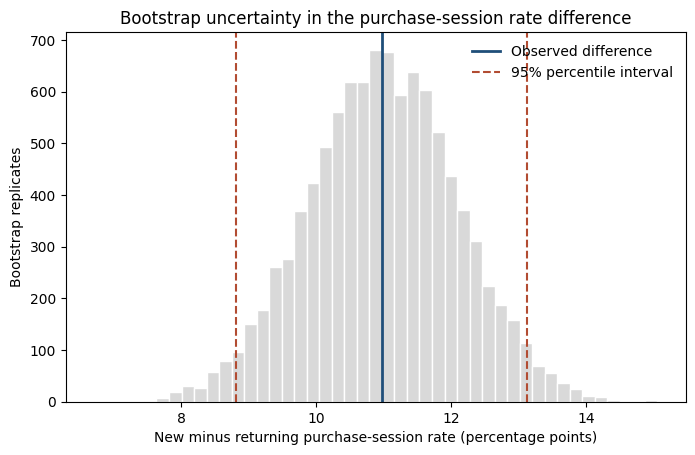

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(
    principal_replicates * 100,
    bins=45,
    color="#d9d9d9",
    edgecolor="white",
)
ax.axvline(
    observed_difference * 100,
    color="#1f4e79",
    linewidth=2,
    label="Observed difference",
)
ax.axvline(
    interval_low * 100,
    color="#b24c32",
    linestyle="--",
    linewidth=1.5,
)
ax.axvline(
    interval_high * 100,
    color="#b24c32",
    linestyle="--",
    linewidth=1.5,
    label="95% percentile interval",
)
ax.set(
    xlabel="New minus returning purchase-session rate (percentage points)",
    ylabel="Bootstrap replicates",
    title="Bootstrap uncertainty in the purchase-session rate difference",
)
ax.legend(frameon=False)
plt.show()

Interpret the observed statistic and the 95% percentile interval in context. Explain the repeated-sampling meaning of 95%, and name the empirical-distribution and resampling-unit assumptions on which the interpretation depends. Do not describe the interval as having a 95% probability of containing a fixed population difference.

**Your interpretation:**

> The observed rate difference is about 10.99 or ~ 11 percentage points, with a 95% bootstrap interval of about 8.7 to 13.3. That 95%  means about 95% of intervals built this way from repeated sampling would contain the true population difference not that this one interval has a 95% chance of containing it. This answers to the fact that the sessions are separate resampling units and an adequate representation of the broader visitor populations.

## Preserve weekend composition

The principal bootstrap resamples all sessions within each visitor type, so weekend composition can vary. The supplied helper instead resamples within the four visitor-type-by-weekend cells at their recorded sizes, recombines the cells for each visitor type, and calculates the same statistic.

In [10]:
def weekend_preserving_bootstrap(data, n_resamples, rng):
    cells = {
        (visitor_type, weekend): cell["purchase"].to_numpy()
        for (visitor_type, weekend), cell in data.groupby(
            ["visitor_type", "weekend"]
        )
    }

    replicates = np.empty(n_resamples)

    for index in range(n_resamples):
        samples = {}

        for visitor_type in ["new", "returning"]:
            sampled_cells = [
                rng.choice(values, size=len(values), replace=True)
                for (cell_visitor_type, _), values in cells.items()
                if cell_visitor_type == visitor_type
            ]
            samples[visitor_type] = np.concatenate(sampled_cells)

        replicates[index] = purchase_rate_difference(
            samples["new"],
            samples["returning"],
        )

    return replicates

In [11]:
structured_replicates = weekend_preserving_bootstrap(
    sessions,
    n_resamples=10_000,
    rng=np.random.default_rng(7130),
)
structured_low, structured_high = np.quantile(
    structured_replicates,
    [0.025, 0.975],
)

design_comparison = pd.DataFrame(
    {
        "resampling design": [
            "Within visitor type",
            "Within visitor type × weekend",
        ],
        "standard error (percentage points)": [
            principal_result.standard_error * 100,
            structured_replicates.std(ddof=1) * 100,
        ],
        "interval low (percentage points)": [
            interval_low * 100,
            structured_low * 100,
        ],
        "interval high (percentage points)": [
            interval_high * 100,
            structured_high * 100,
        ],
    }
)
design_comparison.round(2)

,resampling design,standard error (percentage points),interval low (percentage points),interval high (percentage points)
0,Within visitor type,1.1,8.81,13.12
1,Within visitor type × weekend,1.1,8.86,13.19


### Explain the structured bootstrap

Using the previous code explanations as examples, briefly explain how `groupby`, `rng.choice`, `np.concatenate`, and `replicates[index]` work together to produce the structured bootstrap distribution. You do not need to explain every line. Then compare the two designs: state which allows weekend composition to vary, which fixes the four cell sizes, whether that choice materially changes the result here, and why the design distinction still matters.

**Your response:**

> In order to fix all four cell sizes rather than the two group totals, the groupby divides sessions into four visitor type * weekend cells,rng.choice resamples with replacement inside each one,np.concatenate joins each visitor type's cells back together so the statistic runs the same as always,and replicates [index] stores the result before going on to the next draw. While "with visitor type" allows the weekend mix to vary, "within visitor type * weekend" locks it down. In this case, the difference is negligible (8.81 vs. 8.86 with the same standard error), but it still matters when a confound interacts more strongly with the result.

## Distinguish uncertainty from null-model evidence

HW1a used a permutation distribution to evaluate a no-relationship model. HW1b uses a bootstrap distribution to estimate sample-to-sample variation in a statistic.

In one short paragraph, contrast the permutation and bootstrap procedures: explain what permutation breaks, what bootstrap preserves, and the question each result answers. End with a bounded conclusion about the recorded sessions and one consequential next evidence need.

**Your evidence statement:**

> Though bootstrap maintains the label value connection and resamples it to determine how much the estimate would change, a permutation breaks it to test if the gap is unexpected in the absence of any association. Together, there is a substantial and difficult-to-explain gap that is calculated reasonably well (8.7 to 13.3 points), but it tells nothing about causality or whether it maintains beyond these data. The next step should be to see if it reproduces on a new set of sessions.

## Assistance disclosure

Identify any material assistance, including LLM use, and explain how you checked it and made the submitted explanations your own. Write `None` if you received no material assistance.

**Your disclosure:**

> I used a paraphrasing tool for my grammer/ sentence constructions.